In [22]:
import matplotlib.pyplot as plt

We test $t$ distribution with $df=3$, change the param_vals setting to test for normal distribution!

In [23]:
DEVICE = 'cpu'

### PARAMETER VALUES ###

param_vals = {
    ## Simulation params
    "n_runs": 20,

    ## Data params
    "n": 2000,
    "d": 3,
    "alpha": 0.7, #1 or 0.7
    "distr": "t", #UNI or Normal or t distribution
    'df': 3, #degree of freedom of t distribution

    ## Resampling params
    "init": "ColBT",
    "T": 1000,
    "eta": 0.01
}

# Code from FLOWGEM for generating data

- add data generating mechanism: t distribution

In [24]:
import numpy as np
import torch
import os
import pandas as pd

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy.stats import t as student_t
from scipy.stats import multivariate_normal

param_vals["n_new"] = param_vals["n"]

# Always leave truth
methods = ['truth', "knewimp"] # 'flowgem', 'mice', 'gain', 'hyperimpute', "miri",

save_all_iter = False

save_intermediate = False

def sample_x2_given_x1(X1):
    if param_vals["distr"] == "UNI":
        # conditional CDF: F(x2|x1) = x2 + alpha*(2*x1-1)*(x2^2 - x2)
        # invert this to sample X2 = F_inv(U)
        # Inversion yields quadratic equation: alpha*(2*x1-1)*x2^2 + [1 - alpha*(2*x1-1)]*x2 - u = 0
        # NOTE: CDF is symmetric so the same method can be used to sample X1 given X2
        U = np.random.rand(X1.shape[0])
        a = param_vals["alpha"] * (2*X1 - 1)
        b = 1 - a
        c = -U
        X2 = np.where(np.abs(a) < 1e-10, U/b, (-b + np.sqrt(b**2 - 4*a*c)) / (2*a))
    elif param_vals["distr"] == "Normal":
        X2 = np.random.multivariate_normal(param_vals["alpha"]*X1, (1-param_vals["alpha"]**2)*np.eye(X1.shape[0]))
    else:
        raise NotImplementedError("Chosen 'distr' is not implemented yet.")
    return X2

def sample_truth(n, d):
    if param_vals["distr"] == "UNI":
        X1 = np.random.rand(n)
        X2 = sample_x2_given_x1(X1)
        data = np.column_stack([X1, X2, np.random.rand(n, d-2)])
    elif param_vals["distr"] == "Normal":
        mu = np.zeros(d)
        cov = np.eye(d)
        cov[0,1] = param_vals["alpha"]
        cov[1,0] = param_vals["alpha"]
        data = np.random.multivariate_normal(mu, cov, n)
    elif param_vals["distr"] == "t":
        rho = param_vals["alpha"]
        # correlation matrix for copula
        Sigma = np.array([
            [1.0, rho],
            [rho, 1.0]
        ])
        # Z ~ N(0,Sigma)
        Z = np.random.multivariate_normal(
            mean=np.zeros(2),
            cov=Sigma,
            size=n
        )
        # common scale -> bivariate t
        W = np.random.chisquare(param_vals.get('df'), size=n)
        T = Z / np.sqrt(W[:, None] / param_vals.get('df'))
        # t-copula uniforms
        U12 = student_t.cdf(T, df=param_vals.get('df'))
        # choose t marginals
        X12 = student_t.ppf(U12, df=param_vals.get('df'))
        if d > 2:
            Xrest = np.random.standard_t(
                param_vals.get('df'),
                size=(n, d-2)
            )
            data = np.column_stack([X12, Xrest])
        else:
            data = X12
    else:
        raise NotImplementedError("Chosen 'distr' is not implemented yet.")

    Xdata = torch.from_numpy(data).to(device=DEVICE, dtype=torch.float64)
    X = Xdata[:n, :].detach().clone()
    return X

def impute_bootstrap_per_col(X, M):
    n, d = X.shape
    for j in range(d):
        observed_mask = M[:, j] == 1
        missing_mask = M[:, j] == 0

        observed_values = X[observed_mask, j]
        if observed_values.numel() == 0:
            raise ValueError(f"Value of column {j} is always missing. Need to be observed at least once.")

        num_missing = missing_mask.sum()
        if num_missing > 0:
            rand_idx = torch.randint(
                0, observed_values.shape[0],
                (num_missing,),
                device=X.device
            )
            X[missing_mask, j] = observed_values[rand_idx]

def generate_data(n, d, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Sample X
    X = sample_truth(n, d)
    Xstar = X.detach().clone()

    # Sample M
    if param_vals["distr"] == "UNI":
        X1 = X[:, 0]
        X2 = X[:, 1]
    elif param_vals["distr"] == "Normal":
        normal = torch.distributions.Normal(0.0, 1.0)
        X1 = normal.cdf(X[:, 0])
        X2 = normal.cdf(X[:, 1])
    elif param_vals["distr"] == "t":
        X1 = torch.tensor(
        student_t.cdf(
            X[:,0].numpy(),
            df=param_vals.get('df')
        ),
        dtype=torch.float64
        )
        X2 = torch.tensor(
            student_t.cdf(
                X[:,1].numpy(),
                df=param_vals.get('df')
            ),
            dtype=torch.float64
        )
    else:
        raise NotImplementedError("Chosen 'distr' is not implemented yet.")
    P = torch.stack([(X1 + X2) / 3, (2 - X1) / 3, (1 - X2) / 3], dim=1)
    dist = torch.distributions.Categorical(P)
    choices = dist.sample()
    masks = torch.stack([torch.ones(d), torch.arange(d)!=1, torch.arange(d)!=0])
    M = masks[choices]

    # Substitute missing values with initial imputation
    if isinstance(param_vals["init"], (int, float)):
        X[M == 0] = param_vals["init"]
    elif param_vals["init"] == 'UNI(0,1)':
        X[M == 0] = torch.rand(n,d)[M == 0]
    elif param_vals["init"] == 'N(0.5,1)':
        X[M == 0] = torch.normal(mean=0.5, std=1, size=(n,d))[M == 0]
    elif param_vals["init"] == 'N(0,1)':
        X[M == 0] = torch.normal(mean=0, std=1, size=(n,d))[M == 0]
    elif param_vals["init"] == 'ColBT':
        impute_bootstrap_per_col(X, M)
    elif param_vals["init"] == "mice":
        Xmiss = X.clone()
        Xmiss[M == 0] = torch.nan
        imputer = IterativeImputer(max_iter=10)
        df = imputer.fit_transform(Xmiss.detach().numpy())
        X = torch.tensor(df.values, dtype=torch.float64)
    else:
        raise NotImplementedError("The chosen initial imputation method is not implemented.")

    return X.cpu(), M.cpu(), Xstar.cpu()


# Define the log file path
log_file = './parameter_log.csv'

# Check if the log file exists and read it
if os.path.exists(log_file):
    param_log = pd.read_csv(log_file)
else:
    param_log = pd.DataFrame(columns=['ID', 'n_runs',
                                      'n', 'd', 'alpha', 'distr', 'df',
                                      'init', 'n_new', 'T', 'eta'])

# Check if the parameter setup already exists in the log file
query_str = " & ".join([f"{k} == {repr(v)}" for k, v in param_vals.items()])
matching = param_log.query(query_str) #pd.DataFrame()

if not matching.empty:
    this_id = matching['ID'].iloc[0]
    # Load the existing results
    results_file = f'./results_{this_id}.pt'
    results = torch.load(results_file, weights_only=False)
    print(f"Setup already run under ID {this_id}")
else:
    # Determine the next ID
    if param_log.empty:
        this_id = 1
    else:
        this_id = param_log['ID'].max() + 1
    results_file = f'./results_{this_id}.pt'

    # Append to log file
    param_vals.update({'ID': this_id})
    param_log = pd.concat([param_log, pd.DataFrame([param_vals])], ignore_index=True)

    # Create new dict to save results
    results = {"data": {},
               "metrics": {},
               "Xhat_store": {}}


/tmp/ipykernel_946423/1650810790.py:196: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  param_log = pd.concat([param_log, pd.DataFrame([param_vals])], ignore_index=True)


# Generate data

In [25]:
 # Create new dict to save results
results = {"data": {},
               "metrics": {},
               "Xhat_store": {}}

if __name__ == "__main__":
    if not results["data"]:
        for run in range(param_vals["n_runs"]):
            X0, M, Xstar = generate_data(param_vals["n"], param_vals["d"], seed=run)
            results["data"][run] = {"X0": X0,
                                    "M": M,
                                    "Xstar": Xstar}

# EM with missing values under MAR

E-step
$$
\gamma_{ij}^{(t+1)} = {\pi^{(t)}_j p_{\theta_j^{(t)}}^{(m_i)} (x_i^{(m_i)}) \over \sum_{\ell=1}^k \pi^{(t)}_\ell p_{\theta_\ell^{(t)}}^{(m_i)} (x_i^{(m_i)})}.
$$

$$
p_{\theta_j^{(t)}}^{(m_i)} (x_i^{(m_i)}) = \prod_{\{v: \, m_{iv} = 0\}} \phi \left(\frac{x_{iv} - y_{jv}^{(t)}}{\sigma_{jv}^{(t)}}\right). 
$$

M-step

Update $\mu$
$$
y_{jv}^{(t+1)} = \frac{1}{\sum_{i=1}^{n} (1 - m_{iv}) \gamma_{ij}} \sum_{i=1}^n (1 - m_{iv}) \gamma_{ij} x_{iv}
$$

Update $\sigma$
$$
{\sigma_{jv}^2}^{(t+1)} = \frac{1}{\sum_{i=1}^{n} (1 - m_{iv})\gamma_{ij}} \sum_{i=1}^n (1 - m_{iv}) \gamma_{ij} \left(x_{iv} - y_{jv}^{(t+1)}\right)^2
$$

Update $\pi$
$$
\pi_j^{(t+1)}
= 
\frac{\sum_{i=1}^{n}\gamma_{ij}^{(t+1)}}{n}
$$

In [26]:
# -----------------------------
# masked log Gaussian (FIXED)
# -----------------------------
def log_gaussian_masked(X, M, mu, sigma):
    dtype, device = mu.dtype, mu.device

    X = X.to(dtype=dtype, device=device)
    M = M.to(dtype=dtype, device=device)

    K, d = mu.shape
    N = X.shape[0]

    # --- correct expansion ---
    X = X.unsqueeze(0).expand(K, N, d)
    M = M.unsqueeze(0).expand(K, N, d)

    mu = mu[:, None, :]          # (K,1,d)
    var = (sigma ** 2)[:, None, :]

    log_prob = -0.5 * (
        ((X - mu) ** 2) / var
        + torch.log(2 * torch.pi * var)
    )

    # the log_prob of the missing entries are 0
    log_prob = log_prob * M

    return log_prob.sum(dim=2)  # (K,N)

In [27]:
# -----------------------------
# EM algorithm with missing data (FIXED)
# -----------------------------
def em_gmm_missing(X, M, K, iters=50, eps=1e-6):
    """
    X: (N, d)
    M: (N, d) binary mask
    """

    # --- ensure float32 consistency ---
    X = X.float()
    M = M.float()

    N, d = X.shape
    device = X.device

    # ---- init ----
    idx = torch.randint(0, N, (K,), device=device)
    mu = X[idx] + 0.1 * torch.randn(K, d, device=device)
    sigma = torch.ones(K, d, device=device)
    pi = torch.ones(K, device=device) / K

    for _ in range(iters):

        # =====================
        # E-step
        # =====================
        log_px = log_gaussian_masked(X, M, mu, sigma)  # (K, N)

        log_pi = torch.log(pi + eps).unsqueeze(1)      # (K, 1)

        log_r = log_pi + log_px
        log_r = log_r - torch.logsumexp(log_r, dim=0, keepdim=True)

        r = torch.exp(log_r)  # (K, N)

        # =====================
        # M-step
        # =====================
        Nk = r.sum(dim=1, keepdim=True) + eps  # (K, 1)

        pi = (Nk[:, 0] / N)

        # --- mean update (masked properly) ---
        Xm = X * M  # (N, d)

        mu = (r @ Xm) / (r @ M + eps)

        # =====================
        # variance update (FIXED MASKING)
        # =====================
        diff = X.unsqueeze(0) - mu.unsqueeze(1)  # (K, N, d)

        sigma = torch.sqrt(
            (r.unsqueeze(2) * (diff ** 2) * M.unsqueeze(0)).sum(dim=1)
            / (r @ M + eps)
            + eps
        )

    return mu, sigma, pi

In [28]:
def sample_gmm(mu, sigma, w, n_samples):
    """
    mu: (K, d)
    sigma: (K, d)
    w: (K,)
    n_samples: int

    returns: (n_samples, d)
    """

    _, d = mu.shape

    # normalize weights
    w = torch.softmax(w, dim=0)

    # 1. sample component indices
    z = torch.multinomial(w, n_samples, replacement=True)  # (N,)

    # 2. sample standard normals
    eps = torch.randn(n_samples, d)

    # 3. gather parameters for each sample
    mu_z = mu[z]        # (N, d)
    sigma_z = sigma[z]  # (N, d)

    # 4. reparameterization
    x = mu_z + sigma_z * eps

    return x

In [29]:
def sample_complete_data_gmm(X, M, K, n_samples, iters=50, eps=1e-6):
    mu, sigma, w = em_gmm_missing(X, M, K, iters, eps)
    return sample_gmm(mu, sigma, w, n_samples)

# Compute AIC/BIC

$$
\mathcal L (X, M \mid \mu, \sigma, \pi) = \prod_{i=1}^n \sum_{j=1}^k \pi_{j} \prod_{\{v: m_{iv} = 0\}} \phi (\frac{x_{iv} - y_{jv}}{\sigma_{jv}})
$$

$$
\ell (X, M \mid \mu, \sigma, \pi) = \log \sum_{j=1}^k \exp \left\{\log\pi_{j} + \sum_{\{v: m_{iv} = 0\}} \log \phi (\frac{x_{iv} - y_{jv}}{\sigma_{jv}})\right\}
$$

$$
\text{AIC} = - 2 \ln (\hat{\mathcal L}) + 2 p,
$$
where $p$ is number of parameters, explicitly
$$
p = k \times (d + d) + (k - 1),
$$
$d$ location parameters and $d$ $\sigma$ per component, and $k-1$ mixture empirical measure parameters.

$$
\text{BIC} = - 2 \ln (\hat{\mathcal L}) + p \ln (n),
$$
where $n$ is the sample size.

In [30]:
def observed_loglik(X, M, mu, sigma, pi, eps=1e-12):
    log_px = log_gaussian_masked(X, M, mu, sigma)  # (K,N)

    log_mix = (
        torch.log(pi + eps).unsqueeze(1)
        + log_px
    )

    return torch.logsumexp(log_mix, dim=0).sum()

def aic_bic_gmm_missing(X, M, mu, sigma, pi):
    K, d = mu.shape
    N = len(X)

    loglik = observed_loglik(X, M, mu, sigma, pi)

    p = (2*d + 1)*K - 1

    return -2 * loglik.item() + 2 * p, -2 * loglik.item() + p * np.log(N) # AIC, BIC

# Evaluation by quantile 10% estimation

In [31]:
seed=2
torch.manual_seed(seed)

## Choose $k$-grid with stepsize=50

In [32]:
s = 50 # stepsize

n_samples = 2000
n1 = 10 # number of different ks
n2 = 100 # number of MC
kk = [x * s for x in range(1, n1+1)]
q_estimates_gmm = np.empty((n1, n2))
aic = np.empty(n1)
bic = np.empty(n1)
for i in range(n1):
    data = results['data'][1]['X0']
    M = results['data'][1]['M']
    mu, sigma, pi = em_gmm_missing(data, M, kk[i], iters=50, eps=1e-6)
    q_estimates_gmm[i]= [np.quantile(sample_gmm(mu, sigma, pi, n_samples), 0.1) for _ in range(n2)]
    aic[i], bic[i] = aic_bic_gmm_missing(data, M, mu, sigma, pi)

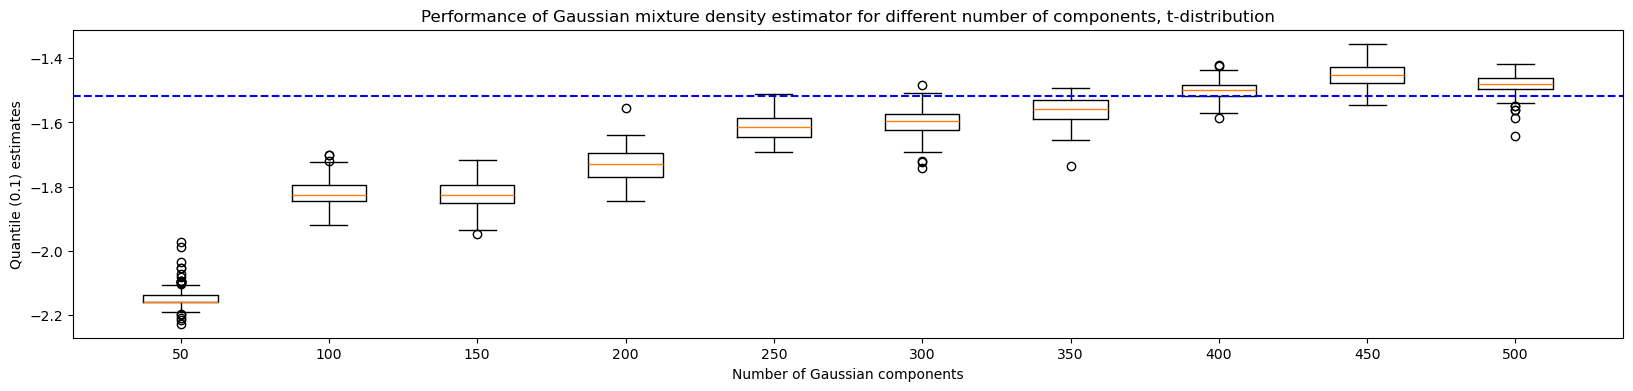

In [33]:
# One boxplot for each row
positions = np.array(kk)
dist = param_vals['distr']

plt.figure(figsize=(20, 4))
plt.boxplot(q_estimates_gmm.T, positions=positions, widths=kk[0]/2)
plt.axhline(y=np.quantile(data, 0.1), color='blue', linestyle='--')
plt.xlabel("Number of Gaussian components")
plt.ylabel("Quantile (0.1) estimates")
plt.xticks(positions, positions.astype(int))
plt.title(f'Performance of Gaussian mixture density estimator for different number of components, {dist}-distribution')
plt.show()

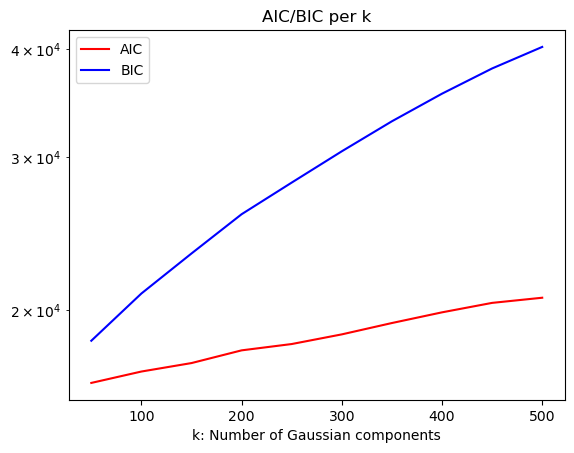

In [34]:
plt.plot(kk, aic, color='r', label='AIC')
plt.plot(kk, bic, color='b', label='BIC')
plt.yscale('log')
plt.xlabel('k: Number of Gaussian components')
plt.title('AIC/BIC per k')
plt.legend()
plt.show()

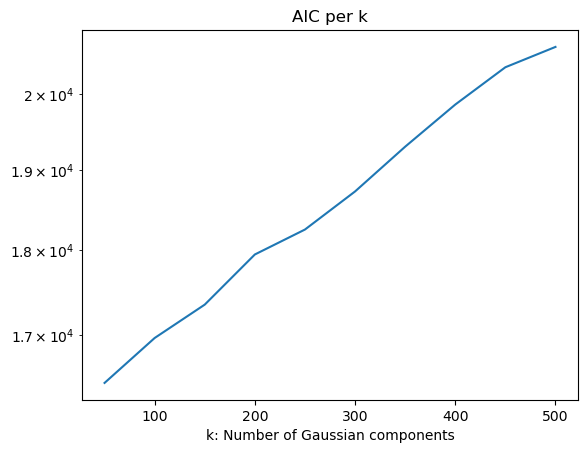

In [35]:
plt.plot(kk, aic)
plt.yscale('log')
plt.xlabel('k: Number of Gaussian components')
plt.title('AIC per k')
plt.show()

## Choose $k$-grid with stepsize=10

In [36]:
s = 10 # stepsize

n_samples = 2000
n1 = 10 # number of different ks
n2 = 100 # number of MC
kk = [x * s for x in range(1, n1+1)]
q_estimates_gmm = np.empty((n1, n2))
aic = np.empty(n1)
bic = np.empty(n1)
for i in range(n1):
    data = results['data'][1]['X0']
    M = results['data'][1]['M']
    mu, sigma, pi = em_gmm_missing(data, M, kk[i], iters=50, eps=1e-6)
    q_estimates_gmm[i]= [np.quantile(sample_gmm(mu, sigma, pi, n_samples), 0.1) for _ in range(n2)]
    aic[i], bic[i] = aic_bic_gmm_missing(data, M, mu, sigma, pi)

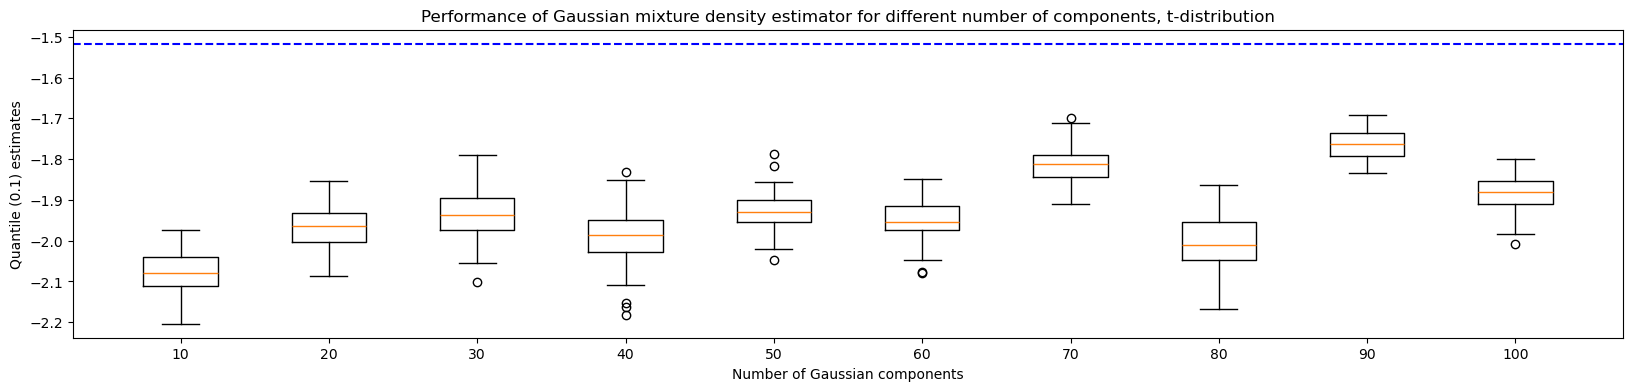

In [37]:
# One boxplot for each row
positions = np.array(kk)
dist = param_vals['distr']

plt.figure(figsize=(20, 4))
plt.boxplot(q_estimates_gmm.T, positions=positions, widths=kk[0]/2)
plt.axhline(y=np.quantile(data, 0.1), color='blue', linestyle='--')
plt.xlabel("Number of Gaussian components")
plt.ylabel("Quantile (0.1) estimates")
plt.xticks(positions, positions.astype(int))
plt.title(f'Performance of Gaussian mixture density estimator for different number of components, {dist}-distribution')
plt.show()

For $t$-distribution we need more components to approximate the density!

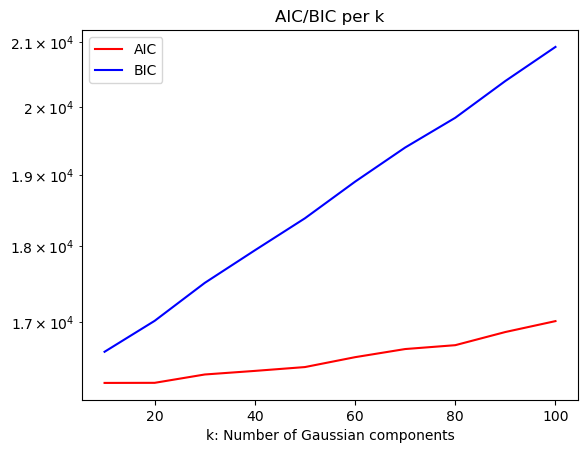

In [38]:
plt.plot(kk, aic, color='r', label='AIC')
plt.plot(kk, bic, color='b', label='BIC')
plt.yscale('log')
plt.xlabel('k: Number of Gaussian components')
plt.title('AIC/BIC per k')
plt.legend()
plt.show()

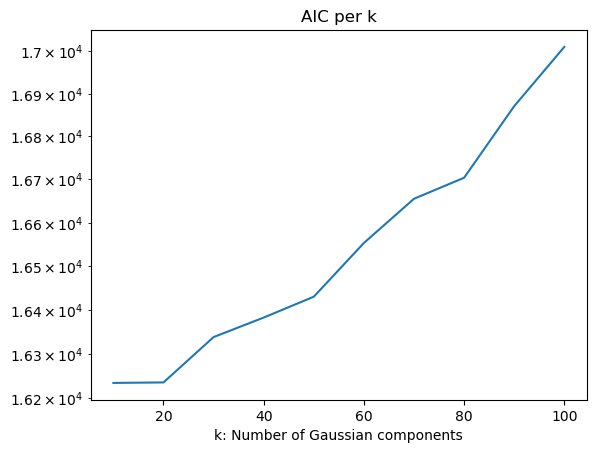

In [39]:
plt.plot(kk, aic)
plt.yscale('log')
plt.xlabel('k: Number of Gaussian components')
plt.title('AIC per k')
plt.show()

Increase the starting number of k!

In [40]:
s = 10 # stepsize

n_samples = 2000
n1 = 10 # number of different ks
n2 = 100 # number of MC
kk = [x * s + 300 for x in range(1, n1+1)]
q_estimates_gmm = np.empty((n1, n2))
aic = np.empty(n1)
bic = np.empty(n1)
for i in range(n1):
    data = results['data'][1]['X0']
    M = results['data'][1]['M']
    mu, sigma, pi = em_gmm_missing(data, M, kk[i], iters=50, eps=1e-6)
    q_estimates_gmm[i]= [np.quantile(sample_gmm(mu, sigma, pi, n_samples), 0.1) for _ in range(n2)]
    aic[i], bic[i] = aic_bic_gmm_missing(data, M, mu, sigma, pi)

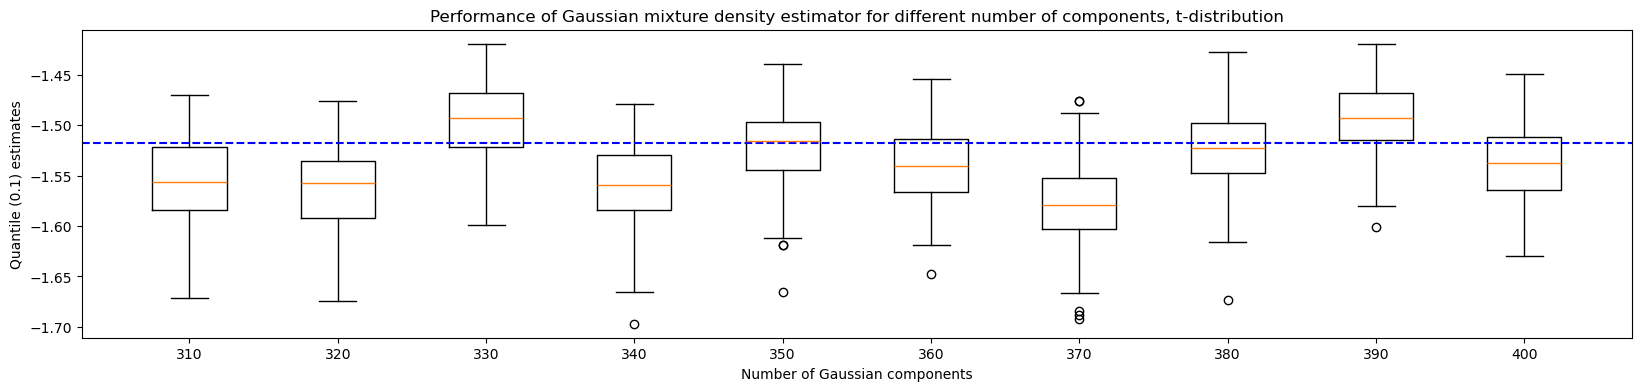

In [41]:
# One boxplot for each row
positions = np.array(kk)
dist = param_vals['distr']

plt.figure(figsize=(20, 4))
plt.boxplot(q_estimates_gmm.T, positions=positions, widths=5) # adjust the widths to improve display of the boxplots -- avoid overlap
plt.axhline(y=np.quantile(data, 0.1), color='blue', linestyle='--')
plt.xlabel("Number of Gaussian components")
plt.ylabel("Quantile (0.1) estimates")
plt.xticks(positions, positions.astype(int))
plt.title(f'Performance of Gaussian mixture density estimator for different number of components, {dist}-distribution')
plt.show()

For small stepsize, we see fluctuation of the performance with k -- within certain range of the values of $k$, the performance similar? -- the choice of $k$ could be multiple!

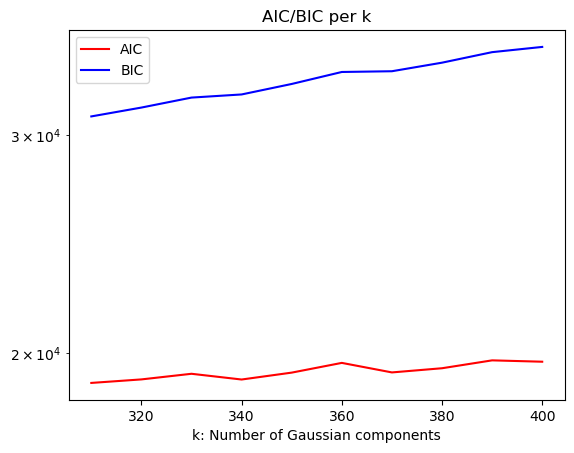

In [42]:
plt.plot(kk, aic, color='r', label='AIC')
plt.plot(kk, bic, color='b', label='BIC')
plt.yscale('log')
plt.xlabel('k: Number of Gaussian components')
plt.title('AIC/BIC per k')
plt.legend()
plt.show()

BIC penalize more than AIC.

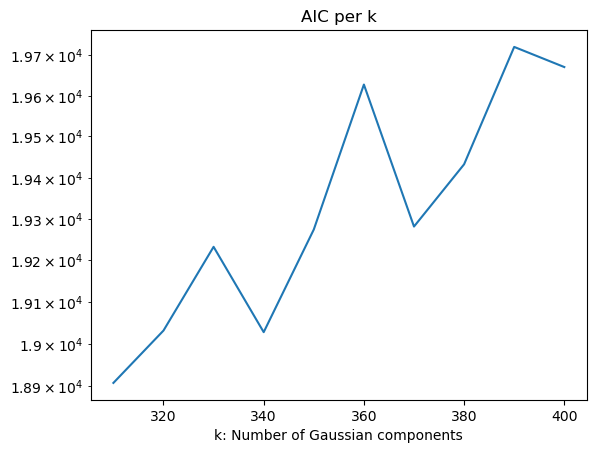

In [43]:
plt.plot(kk, aic)
plt.yscale('log')
plt.xlabel('k: Number of Gaussian components')
plt.title('AIC per k')
plt.show()

With small stepsize we see the AIC is wiggled rather than increase with $k$! Both AIC and BIC do not look like a good criterion for choosing $k$.